In [19]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC

In [20]:
df = pd.read_csv("car_acceptability.csv")
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [21]:
le = LabelEncoder()

df['buying price'] = le.fit_transform(df['buying price'])
df['maintenance cost'] =le.fit_transform(df['maintenance cost'])
df['lug_boot']=le.fit_transform(df['lug_boot'])
df['safety']=le.fit_transform(df['safety'])
df['evaluation']=le.fit_transform(df['evaluation'])

In [22]:
X=df.drop("evaluation",axis=1)
Y=df['evaluation']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, Y_train)

SVC(kernel='linear')

In [14]:
Y_pred = svm_model.predict(X_test)

In [17]:
print("Accuracy:",accuracy_score(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
print("n\Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.7138728323699421
n\Confusion Matrix:
 [[ 12   0  65   0]
 [  0   0  15   0]
 [  2   0 235   0]
 [ 12   0   5   0]]


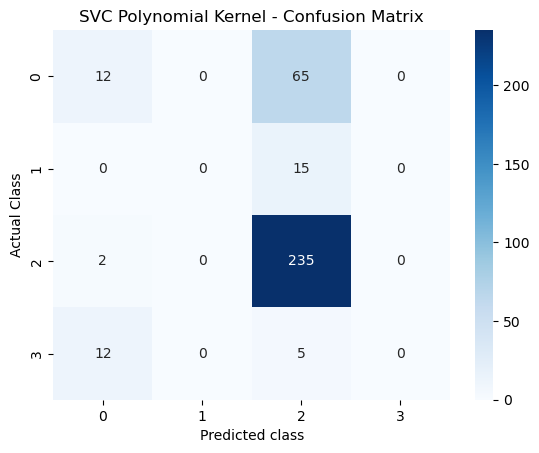

In [23]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("Actual Class")
plt.title("SVC Polynomial Kernel - Confusion Matrix")
plt.show()

In [24]:
svm_model = SVC(kernel='poly')
svm_model.fit(X_train, Y_train)

SVC(kernel='poly')

In [25]:
Y_pred = svm_model.predict(X_test)

In [26]:
print("Accuracy:",accuracy_score(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
print("n\Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.838150289017341
n\Confusion Matrix:
 [[ 50   0  26   1]
 [  6   4   2   3]
 [ 13   0 224   0]
 [  4   0   1  12]]


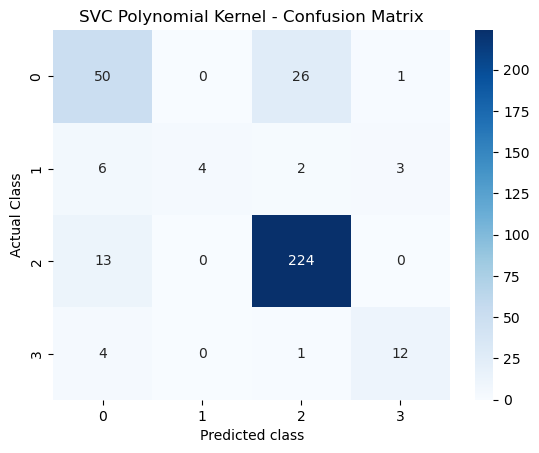

In [27]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("Actual Class")
plt.title("SVC Polynomial Kernel - Confusion Matrix")
plt.show()